In [38]:
import torch, random, numpy as np, os
import math
import torch.nn as nn
import torchvision.models
from torch.nn import functional as F
from torchvision.models import resnet34
from scipy.optimize import linear_sum_assignment
from collections import defaultdict

In [39]:
def seed_everything(seed: int = 1337):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(1)

In [40]:
INPUT_TENSOR = torch.randn(2, 3, 640, 640)
print(INPUT_TENSOR.shape)

torch.Size([2, 3, 640, 640])


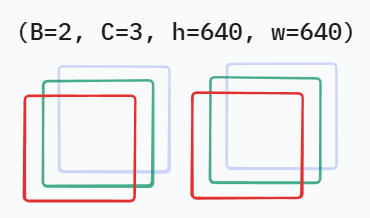

In [41]:
backbone = nn.Sequential(*list(resnet34(
            weights=torchvision.models.ResNet34_Weights.IMAGENET1K_V1,
            norm_layer=torchvision.ops.FrozenBatchNorm2d
        ).children())[:-2])

In [42]:
resnet_out = backbone(INPUT_TENSOR)
print(resnet_out.shape)

torch.Size([2, 512, 20, 20])


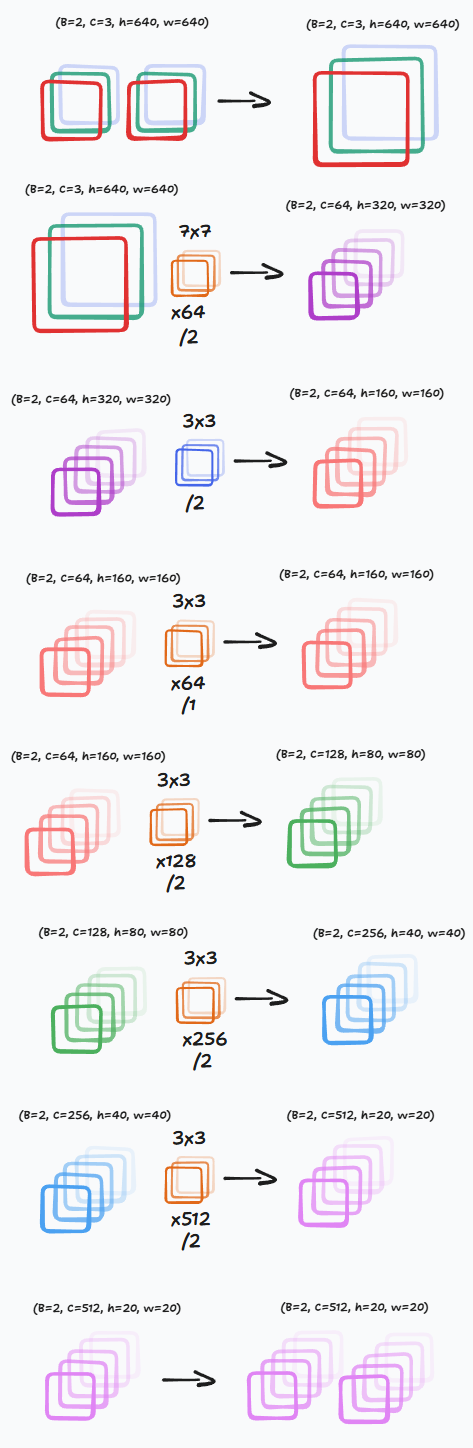

In [43]:
backbone_proj = nn.Conv2d(512, 256, kernel_size=1)

In [44]:
conv_out = backbone_proj(resnet_out)
print(conv_out.shape)

torch.Size([2, 256, 20, 20])


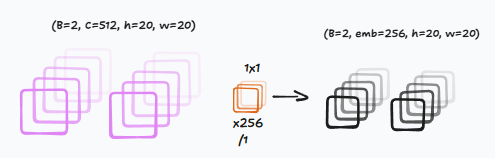

In [45]:
conv_out_rh = conv_out.reshape(2, 256, 20 * 20)
print(conv_out_rh.shape)

torch.Size([2, 256, 400])


In [46]:
conv_out_tr = conv_out_rh.transpose(1, 2)
print(conv_out_tr.shape)

torch.Size([2, 400, 256])


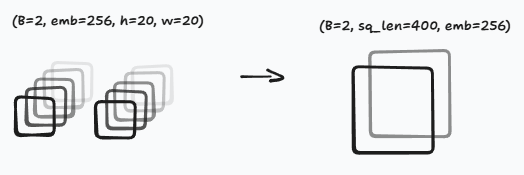